
# Van der Pol learning with `torchdiffeq`

This notebook mirrors the spirit of your original Van der Pol experiment, but swaps the **custom Neural ODE integrator** for **`torchdiffeq`**.

What is included:

- a discrete residual baseline in plain PyTorch
- a `torchdiffeq` Neural ODE with fixed-step **Euler**
- a `torchdiffeq` Neural ODE with fixed-step **RK4**
- a `torchdiffeq` Neural ODE with adaptive **Dormand–Prince (`dopri5`)**
- an optional tolerance sweep for the adaptive solver

A note on the ResNet side: for low-dimensional trajectory rollout like Van der Pol, there is no widely used off-the-shelf `torchvision`-style ResNet module that is a clean fit in the same way as for images. So the baseline here is kept as an idiomatic PyTorch residual MLP stack, while the main swap of interest is the ODE solver backend.



## 0. Install `torchdiffeq` if needed

If `torchdiffeq` is already available, the next cell does nothing.


In [1]:

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torchdiffeq") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchdiffeq"])
    print("Installed torchdiffeq.")
else:
    print("torchdiffeq is already installed.")


torchdiffeq is already installed.


## 1. Imports

In [2]:

import json
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from torchdiffeq import odeint, odeint_adjoint


## 2. Experiment configuration

In [3]:

# -----------------------------------------------------------------------------
# Choose a preset.
#
# 'fast'  : quick smoke test / laptop-friendly
# 'full'  : closer to the scale of the original notebook
# -----------------------------------------------------------------------------
PRESET = "fast"  # change to "full" for a heavier comparison

# Whether to expose time t to the vector field as an extra input feature.
# Keeping this False matches your original autonomous setup more closely.
TIME_DEPENDENT_VECTOR_FIELD = False

# Toggle whether you want to include an adjoint-backed variant.
# This is off by default because the notebook is meant to stay simple and fast.
INCLUDE_ADJOINT_VARIANT = False

if PRESET == "fast":
    SEEDS = [0]
    N_TRAIN, N_VAL, N_TEST = 128, 32, 32
    BATCH_SIZE = 32
    EPOCHS = 60
    HIDDEN_DIM = 48
    NODE_HIDDEN_DIM = 48
    DOPRI5_RTOL = 1e-4
    DOPRI5_ATOL = 1e-6
elif PRESET == "full":
    SEEDS = [0, 1, 2, 3, 4]
    N_TRAIN, N_VAL, N_TEST = 256, 64, 64
    BATCH_SIZE = 32
    EPOCHS = 150
    HIDDEN_DIM = 64
    NODE_HIDDEN_DIM = 64
    DOPRI5_RTOL = 1e-4
    DOPRI5_ATOL = 1e-6
else:
    raise ValueError("PRESET must be either 'fast' or 'full'.")

# Van der Pol parameter and training grid
MU = 3.0
T0, T1 = 0.0, 10.0
N_TIME = 101
T_EVAL = np.linspace(T0, T1, N_TIME, dtype=np.float64)
N_STEPS = N_TIME - 1
DT = float(T_EVAL[1] - T_EVAL[0])

# Dense grids for plotting only
N_TIME_PLOT = 4001
T_EVAL_PLOT = np.linspace(T0, T1, N_TIME_PLOT, dtype=np.float64)

PHASE_TRAJ_T1 = 30.0
N_TIME_PHASE = 6001
T_EVAL_PHASE = np.linspace(T0, PHASE_TRAJ_T1, N_TIME_PHASE, dtype=np.float64)

INIT_LOW = np.array([-2.5, -2.5], dtype=np.float32)
INIT_HIGH = np.array([2.5, 2.5], dtype=np.float32)

LR = 1e-3
WEIGHT_DECAY = 1e-6

MODEL_ORDER = [
    "resnet",
    "node_torchdiffeq_euler",
    "node_torchdiffeq_rk4",
    "node_torchdiffeq_dopri5",
]

if INCLUDE_ADJOINT_VARIANT:
    MODEL_ORDER.append("node_torchdiffeq_dopri5_adjoint")

RESULTS_DIR = Path("results/torchdiffeq_van_der_pol")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Preset:", PRESET)
print("Device:", device)
print("Seeds:", SEEDS)
print("Training samples:", N_TRAIN)
print("Validation samples:", N_VAL)
print("Test samples:", N_TEST)
print("Epochs:", EPOCHS)
print("Time grid points:", N_TIME)
print("dt:", DT)
# print("Results dir:", RESULTS_DIR.resolve())


Preset: fast
Device: cpu
Seeds: [0]
Training samples: 128
Validation samples: 32
Test samples: 32
Epochs: 60
Time grid points: 101
dt: 0.1
Results dir: /Users/talgat/git_repos/neural-odes-tdk/notebooks/results/torchdiffeq_van_der_pol


## 3. Reproducibility helpers

In [4]:

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

try:
    torch.set_num_threads(1)
except RuntimeError:
    pass


## 4. True Van der Pol system and dataset generation

In [5]:

def van_der_pol(t, z, mu=MU):
    x, v = z
    dx = v
    dv = mu * (1.0 - x**2) * v - x
    return np.array([dx, dv], dtype=np.float64)

def solve_true_trajectory(z0, t_eval=T_EVAL, mu=MU):
    sol = solve_ivp(
        fun=lambda t, z: van_der_pol(t, z, mu=mu),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=np.asarray(z0, dtype=np.float64),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(f"Trajectory generation failed: {sol.message}")
    return sol.y.T.astype(np.float32)

def sample_initial_conditions(n, low=INIT_LOW, high=INIT_HIGH):
    return np.random.uniform(low=low, high=high, size=(n, 2)).astype(np.float32)

def make_dataset(n_samples):
    z0s = sample_initial_conditions(n_samples)
    trajectories = np.stack([solve_true_trajectory(z0) for z0 in z0s], axis=0)
    return z0s, trajectories

def make_dataloaders(train_z0, train_traj, val_z0, val_traj, test_z0, test_traj):
    train_ds = TensorDataset(torch.from_numpy(train_z0), torch.from_numpy(train_traj))
    val_ds = TensorDataset(torch.from_numpy(val_z0), torch.from_numpy(val_traj))
    test_ds = TensorDataset(torch.from_numpy(test_z0), torch.from_numpy(test_traj))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


## 5. Models

In [6]:

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=2, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------------------------
# Residual baseline (plain PyTorch)
# ------------------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=HIDDEN_DIM, dt=DT):
        super().__init__()
        self.dt = dt
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return z + self.dt * self.f(z)

class ResNetTrajectoryModel(nn.Module):
    def __init__(self, num_blocks=N_STEPS, state_dim=2, hidden_dim=HIDDEN_DIM, dt=DT):
        super().__init__()
        self.blocks = nn.ModuleList(
            [ResidualBlock(state_dim=state_dim, hidden_dim=hidden_dim, dt=dt) for _ in range(num_blocks)]
        )
        self.last_nfe = 0  # for apples-to-apples accounting

    def forward(self, z0):
        z = z0
        zs = [z]
        for block in self.blocks:
            z = block(z)
            zs.append(z)
        self.last_nfe = len(self.blocks)
        return torch.stack(zs, dim=1)

# ------------------------------------------------------------------
# torchdiffeq Neural ODE
# ------------------------------------------------------------------
class ODEFunc(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=NODE_HIDDEN_DIM, time_dependent=TIME_DEPENDENT_VECTOR_FIELD):
        super().__init__()
        self.time_dependent = time_dependent
        in_dim = state_dim + (1 if time_dependent else 0)
        self.net = MLP(in_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)
        self.nfe = 0

    def forward(self, t, z):
        self.nfe += 1
        if self.time_dependent:
            t_feature = torch.ones_like(z[..., :1]) * t
            z = torch.cat([z, t_feature], dim=-1)
        return self.net(z)

    def reset_nfe(self):
        self.nfe = 0

class TorchdiffeqNODE(nn.Module):
    def __init__(
        self,
        method="dopri5",
        state_dim=2,
        hidden_dim=NODE_HIDDEN_DIM,
        n_steps=N_STEPS,
        dt=DT,
        time_dependent=TIME_DEPENDENT_VECTOR_FIELD,
        adjoint=False,
        rtol=1e-4,
        atol=1e-6,
        options=None,
    ):
        super().__init__()
        self.method = method
        self.adjoint = adjoint
        self.rtol = rtol
        self.atol = atol
        self.options = {} if options is None else dict(options)
        self.n_steps = n_steps
        self.dt = dt
        self.func = ODEFunc(state_dim=state_dim, hidden_dim=hidden_dim, time_dependent=time_dependent)
        self.last_nfe = 0

    def forward(self, z0, t_eval=None):
        self.func.reset_nfe()

        if t_eval is None:
            t_eval = torch.linspace(T0, T1, self.n_steps + 1, device=z0.device, dtype=z0.dtype)

        odeint_fn = odeint_adjoint if self.adjoint else odeint
        traj = odeint_fn(
            self.func,
            z0,
            t_eval,
            method=self.method,
            rtol=self.rtol,
            atol=self.atol,
            options=self.options,
        )

        # torchdiffeq returns [time, batch, state]; for convenience use [batch, time, state]
        self.last_nfe = int(self.func.nfe)
        return traj.permute(1, 0, 2)

def build_models():
    models = {
        "resnet": ResNetTrajectoryModel(num_blocks=N_STEPS, hidden_dim=HIDDEN_DIM),
        "node_torchdiffeq_euler": TorchdiffeqNODE(
            method="euler",
            hidden_dim=NODE_HIDDEN_DIM,
            options={"step_size": DT},
        ),
        "node_torchdiffeq_rk4": TorchdiffeqNODE(
            method="rk4",
            hidden_dim=NODE_HIDDEN_DIM,
            options={"step_size": DT},
        ),
        "node_torchdiffeq_dopri5": TorchdiffeqNODE(
            method="dopri5",
            hidden_dim=NODE_HIDDEN_DIM,
            rtol=DOPRI5_RTOL,
            atol=DOPRI5_ATOL,
        ),
    }

    if INCLUDE_ADJOINT_VARIANT:
        models["node_torchdiffeq_dopri5_adjoint"] = TorchdiffeqNODE(
            method="dopri5",
            hidden_dim=NODE_HIDDEN_DIM,
            rtol=DOPRI5_RTOL,
            atol=DOPRI5_ATOL,
            adjoint=True,
        )

    return models



### Quick sanity check: parameter counts


In [7]:

for name, model in build_models().items():
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:32s}  parameters = {n_params:,}")


resnet                            parameters = 259,400
node_torchdiffeq_euler            parameters = 2,594
node_torchdiffeq_rk4              parameters = 2,594
node_torchdiffeq_dopri5           parameters = 2,594


## 6. Metrics and training utilities

In [8]:

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def mse_loss(pred, target):
    return torch.mean((pred - target) ** 2)

def relative_l2_error(pred, target):
    return np.linalg.norm(pred - target) / np.linalg.norm(target)

def final_state_rmse(pred, target):
    diff = pred[:, -1, :] - target[:, -1, :]
    return float(np.sqrt(np.mean(diff ** 2)))

@torch.no_grad()
def evaluate_model(model, loader, t_eval_tensor):
    model.eval()
    total_loss = 0.0
    total_n = 0
    total_forward_nfe = 0
    preds_all = []
    targets_all = []

    for z0, traj in loader:
        z0 = z0.to(device)
        traj = traj.to(device)

        if isinstance(model, TorchdiffeqNODE):
            pred = model(z0, t_eval=t_eval_tensor)
        else:
            pred = model(z0)

        loss = mse_loss(pred, traj)
        batch_size = z0.shape[0]

        total_loss += loss.item() * batch_size
        total_n += batch_size
        total_forward_nfe += int(getattr(model, "last_nfe", 0)) * batch_size

        preds_all.append(pred.detach().cpu())
        targets_all.append(traj.detach().cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()

    return {
        "loss": total_loss / total_n,
        "pred": preds_all,
        "true": targets_all,
        "mean_forward_nfe_per_traj": total_forward_nfe / total_n if total_n > 0 else np.nan,
        "total_forward_nfe": total_forward_nfe,
    }

def train_model(model, train_loader, val_loader, t_eval_tensor, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val = float("inf")
    total_train_forward_nfe = 0

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_n = 0
        epoch_forward_nfe = 0

        for z0, traj in train_loader:
            z0 = z0.to(device)
            traj = traj.to(device)

            optimizer.zero_grad()

            if isinstance(model, TorchdiffeqNODE):
                pred = model(z0, t_eval=t_eval_tensor)
            else:
                pred = model(z0)

            loss = mse_loss(pred, traj)
            loss.backward()
            optimizer.step()

            batch_size = z0.shape[0]
            running_loss += loss.item() * batch_size
            total_n += batch_size
            epoch_forward_nfe += int(getattr(model, "last_nfe", 0)) * batch_size

        total_train_forward_nfe += epoch_forward_nfe
        train_loss = running_loss / total_n
        val_info = evaluate_model(model, val_loader, t_eval_tensor)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_info["loss"],
                "train_forward_nfe_total_epoch": epoch_forward_nfe,
                "train_forward_nfe_per_traj_epoch": epoch_forward_nfe / total_n,
            }
        )

        if val_info["loss"] < best_val:
            best_val = val_info["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df, elapsed, total_train_forward_nfe

def make_result_row(seed, model_name, trained_model, train_time, total_train_forward_nfe, train_info, val_info, test_info):
    return {
        "seed": int(seed),
        "model": model_name,
        "parameters": int(count_parameters(trained_model)),
        "train_time_sec": float(train_time),
        "total_train_forward_nfe": float(total_train_forward_nfe),
        "mean_train_forward_nfe_per_traj": float(total_train_forward_nfe / (N_TRAIN * EPOCHS)),
        "train_loss": float(train_info["loss"]),
        "val_loss": float(val_info["loss"]),
        "test_loss": float(test_info["loss"]),
        "test_rel_l2_err": float(relative_l2_error(test_info["pred"], test_info["true"])),
        "test_final_state_rmse": float(final_state_rmse(test_info["pred"], test_info["true"])),
        "mean_test_forward_nfe_per_traj": float(test_info["mean_forward_nfe_per_traj"]),
    }

def aggregate_results(results_df, model_order=None):
    grouped = (
        results_df.groupby("model")
        .agg(
            parameters=("parameters", "first"),
            train_time_mean=("train_time_sec", "mean"),
            train_time_std=("train_time_sec", "std"),
            total_train_forward_nfe_mean=("total_train_forward_nfe", "mean"),
            total_train_forward_nfe_std=("total_train_forward_nfe", "std"),
            mean_train_forward_nfe_per_traj_mean=("mean_train_forward_nfe_per_traj", "mean"),
            mean_train_forward_nfe_per_traj_std=("mean_train_forward_nfe_per_traj", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
            test_loss_mean=("test_loss", "mean"),
            test_loss_std=("test_loss", "std"),
            test_rel_l2_err_mean=("test_rel_l2_err", "mean"),
            test_rel_l2_err_std=("test_rel_l2_err", "std"),
            test_final_state_rmse_mean=("test_final_state_rmse", "mean"),
            test_final_state_rmse_std=("test_final_state_rmse", "std"),
            mean_test_forward_nfe_per_traj_mean=("mean_test_forward_nfe_per_traj", "mean"),
            mean_test_forward_nfe_per_traj_std=("mean_test_forward_nfe_per_traj", "std"),
        )
        .reset_index()
    )

    if model_order is not None:
        grouped["model"] = pd.Categorical(grouped["model"], categories=model_order, ordered=True)
        grouped = grouped.sort_values("model").reset_index(drop=True)

    return grouped


## 7. Run the experiments

In [9]:

all_rows = []
all_histories = []
reference_bundle = None

for seed in SEEDS:
    print("=" * 80)
    print(f"Running seed {seed}")
    set_seed(seed)

    train_z0, train_traj = make_dataset(N_TRAIN)
    val_z0, val_traj = make_dataset(N_VAL)
    test_z0, test_traj = make_dataset(N_TEST)

    train_loader, val_loader, test_loader = make_dataloaders(
        train_z0, train_traj, val_z0, val_traj, test_z0, test_traj
    )

    t_eval_tensor = torch.tensor(T_EVAL, dtype=torch.float32, device=device)
    model_dict = build_models()

    seed_rows = []
    seed_histories = {}

    for model_name, model in model_dict.items():
        print(f"  -> training {model_name}")
        trained_model, history_df, train_time, total_train_forward_nfe = train_model(
            model,
            train_loader,
            val_loader,
            t_eval_tensor,
            epochs=EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

        train_info = evaluate_model(trained_model, train_loader, t_eval_tensor)
        val_info = evaluate_model(trained_model, val_loader, t_eval_tensor)
        test_info = evaluate_model(trained_model, test_loader, t_eval_tensor)

        row = make_result_row(
            seed=seed,
            model_name=model_name,
            trained_model=trained_model,
            train_time=train_time,
            total_train_forward_nfe=total_train_forward_nfe,
            train_info=train_info,
            val_info=val_info,
            test_info=test_info,
        )
        seed_rows.append(row)

        history_df = history_df.copy()
        history_df["seed"] = seed
        history_df["model"] = model_name
        seed_histories[model_name] = history_df

        if reference_bundle is None:
            reference_bundle = {
                "seed": seed,
                "train_z0": train_z0,
                "train_traj": train_traj,
                "val_z0": val_z0,
                "val_traj": val_traj,
                "test_z0": test_z0,
                "test_traj": test_traj,
                "models": {model_name: trained_model.cpu()},
            }
        elif seed == reference_bundle["seed"]:
            reference_bundle["models"][model_name] = trained_model.cpu()

        print(
            f"     val_loss={row['val_loss']:.4e} | test_loss={row['test_loss']:.4e} | "
            f"mean test NFE/traj={row['mean_test_forward_nfe_per_traj']:.2f}"
        )

    all_rows.append(pd.DataFrame(seed_rows))

    for model_name, hist_df in seed_histories.items():
        all_histories.append(hist_df)

results_df = pd.concat(all_rows, ignore_index=True)
histories_df = pd.concat(all_histories, ignore_index=True)
results_df


Running seed 0
  -> training resnet
     val_loss=1.3836e+00 | test_loss=1.3390e+00 | mean test NFE/traj=100.00
  -> training node_torchdiffeq_euler
     val_loss=1.5718e+00 | test_loss=1.4539e+00 | mean test NFE/traj=100.00
  -> training node_torchdiffeq_rk4
     val_loss=1.4706e+00 | test_loss=1.3758e+00 | mean test NFE/traj=400.00
  -> training node_torchdiffeq_dopri5
     val_loss=1.5645e+00 | test_loss=1.4295e+00 | mean test NFE/traj=86.00


,seed,model,parameters,train_time_sec,total_train_forward_nfe,mean_train_forward_nfe_per_traj,train_loss,val_loss,test_loss,test_rel_l2_err,test_final_state_rmse,mean_test_forward_nfe_per_traj
0,0,resnet,259400,3.262710,768000.0,100.000,1.340731,1.383630,1.339015,0.762042,0.883257,100.0
1,0,node_torchdiffeq_euler,2594,2.383642,768000.0,100.000,1.508800,1.571755,1.453915,0.794064,1.127280,100.0
2,0,node_torchdiffeq_rk4,2594,9.086886,3072000.0,400.000,1.422989,1.470634,1.375836,0.772448,1.047717,400.0
3,0,node_torchdiffeq_dopri5,2594,4.339997,716352.0,93.275,1.492473,1.564496,1.429517,0.787374,1.138484,86.0


## 8. Main result tables

In [10]:

if len(SEEDS) == 1:
    display_df = results_df.copy()
    display_df["model"] = pd.Categorical(display_df["model"], categories=MODEL_ORDER, ordered=True)
    display_df = display_df.sort_values("model").reset_index(drop=True)
    display_df
else:
    summary_df = aggregate_results(results_df, model_order=MODEL_ORDER)
    summary_df



### Save CSV outputs


In [11]:

results_df.to_csv(RESULTS_DIR / "all_runs.csv", index=False)
histories_df.to_csv(RESULTS_DIR / "all_histories.csv", index=False)

config = {
    "preset": PRESET,
    "seeds": SEEDS,
    "mu": MU,
    "time_horizon": [T0, T1],
    "n_time": N_TIME,
    "dt": DT,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "n_test": N_TEST,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "hidden_dim": HIDDEN_DIM,
    "node_hidden_dim": NODE_HIDDEN_DIM,
    "time_dependent_vector_field": TIME_DEPENDENT_VECTOR_FIELD,
    "include_adjoint_variant": INCLUDE_ADJOINT_VARIANT,
    "dopri5_rtol": DOPRI5_RTOL,
    "dopri5_atol": DOPRI5_ATOL,
}
with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

# print("Saved results to:", RESULTS_DIR.resolve())


Saved results to: /Users/talgat/git_repos/neural-odes-tdk/notebooks/results/torchdiffeq_van_der_pol


## 9. Representative rollout plots

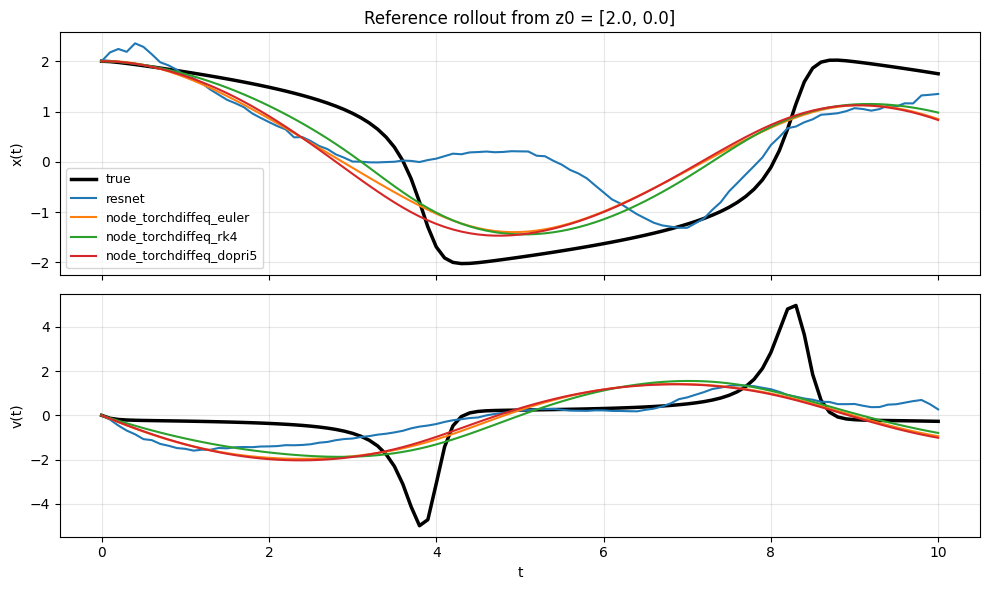

In [12]:

seed = reference_bundle["seed"]
models = reference_bundle["models"]
test_z0 = reference_bundle["test_z0"]
test_traj = reference_bundle["test_traj"]

# pick a representative initial condition
z0_ref = torch.tensor([[2.0, 0.0]], dtype=torch.float32)
t_eval_tensor = torch.tensor(T_EVAL, dtype=torch.float32)

with torch.no_grad():
    preds = {}
    for model_name, model in models.items():
        model.eval()
        if isinstance(model, TorchdiffeqNODE):
            pred = model(z0_ref, t_eval=t_eval_tensor).squeeze(0).cpu().numpy()
        else:
            pred = model(z0_ref).squeeze(0).cpu().numpy()
        preds[model_name] = pred

true_ref = solve_true_trajectory(np.array([2.0, 0.0], dtype=np.float32), t_eval=T_EVAL)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax_idx, ylabel in enumerate(["x(t)", "v(t)"]):
    axes[ax_idx].plot(T_EVAL, true_ref[:, ax_idx], label="true", linewidth=2.5, color="black")
    for model_name in MODEL_ORDER:
        if model_name in preds:
            axes[ax_idx].plot(T_EVAL, preds[model_name][:, ax_idx], label=model_name, linewidth=1.5)
    axes[ax_idx].set_ylabel(ylabel)
    axes[ax_idx].grid(alpha=0.3)

axes[-1].set_xlabel("t")
axes[0].set_title("Reference rollout from z0 = [2.0, 0.0]")
axes[0].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 10. Phase portrait on the training horizon

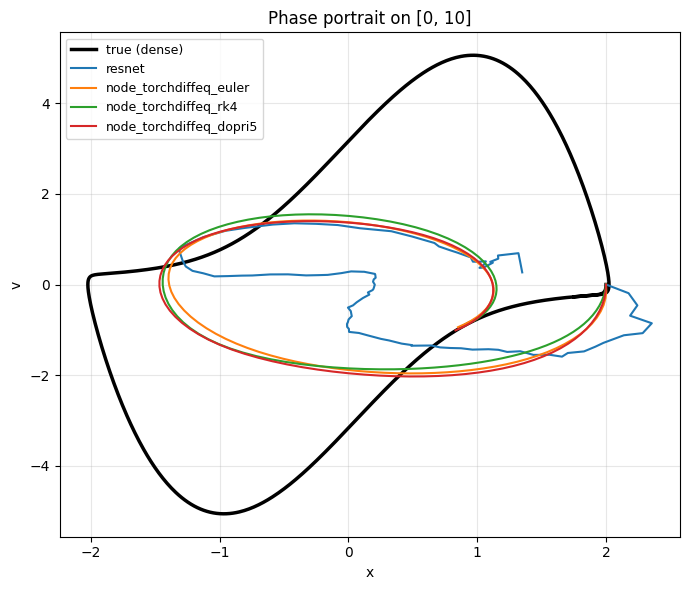

In [13]:

true_ref_dense = solve_true_trajectory(np.array([2.0, 0.0], dtype=np.float32), t_eval=T_EVAL_PLOT)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(true_ref_dense[:, 0], true_ref_dense[:, 1], color="black", linewidth=2.5, label="true (dense)")

for model_name in MODEL_ORDER:
    if model_name in preds:
        ax.plot(preds[model_name][:, 0], preds[model_name][:, 1], linewidth=1.5, label=model_name)

ax.set_xlabel("x")
ax.set_ylabel("v")
ax.set_title("Phase portrait on [0, 10]")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 11. Mean validation-loss curves

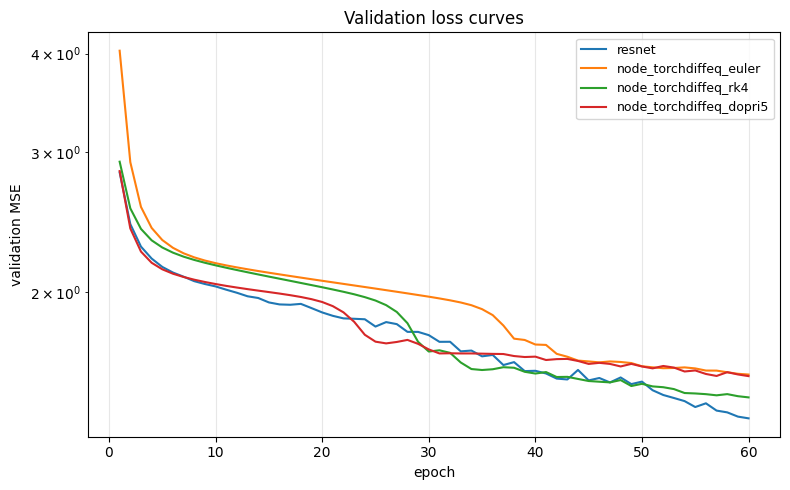

In [14]:

plot_df = histories_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODEL_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
for model_name in MODEL_ORDER:
    subset = plot_df[plot_df["model"] == model_name].copy()
    if len(subset) == 0:
        continue
    grouped = subset.groupby("epoch")["val_loss"].agg(["mean", "std"]).reset_index()
    ax.plot(grouped["epoch"], grouped["mean"], label=model_name)
    if len(SEEDS) > 1:
        ax.fill_between(
            grouped["epoch"],
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.2,
        )

ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("validation MSE")
ax.set_title("Validation loss curves")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()



## 12. Adaptive solver tolerance sweep

This last section evaluates the **same trained `dopri5` model** under different tolerances, so you can see the trade-off between accuracy and solver work (`NFE`).

This does **not** retrain the model; it only changes the solver settings at evaluation time.


In [15]:

if "node_torchdiffeq_dopri5" not in models:
    raise RuntimeError("Adaptive dopri5 model not found in reference bundle.")

adaptive_model = models["node_torchdiffeq_dopri5"].cpu()
adaptive_model.eval()

tol_grid = [
    (1e-3, 1e-5),
    (1e-4, 1e-6),
    (1e-5, 1e-7),
]

t_eval_tensor = torch.tensor(T_EVAL, dtype=torch.float32)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(reference_bundle["test_z0"]), torch.from_numpy(reference_bundle["test_traj"])),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

rows = []
orig_rtol, orig_atol = adaptive_model.rtol, adaptive_model.atol

for rtol, atol in tol_grid:
    adaptive_model.rtol = rtol
    adaptive_model.atol = atol
    info = evaluate_model(adaptive_model, test_loader, t_eval_tensor)
    rows.append(
        {
            "rtol": rtol,
            "atol": atol,
            "test_loss": info["loss"],
            "mean_test_forward_nfe_per_traj": info["mean_forward_nfe_per_traj"],
            "test_rel_l2_err": relative_l2_error(info["pred"], info["true"]),
            "test_final_state_rmse": final_state_rmse(info["pred"], info["true"]),
        }
    )

adaptive_model.rtol, adaptive_model.atol = orig_rtol, orig_atol

tol_df = pd.DataFrame(rows)
tol_df


,rtol,atol,test_loss,mean_test_forward_nfe_per_traj,test_rel_l2_err,test_final_state_rmse
0,0.00100,1.000000e-05,1.430420,56.0,0.787622,1.144256
1,0.00010,1.000000e-06,1.429517,86.0,0.787374,1.138484
2,0.00001,1.000000e-07,1.429444,128.0,0.787353,1.138134



## 13. Notes

- The **fixed-step** `torchdiffeq` models use the same training grid as the data (`step_size = dt`).
- The **adaptive** model uses `dopri5`; its forward cost changes during training and across trajectories.
- If you want something closer to your original notebook:
  - switch `PRESET = "full"`
  - optionally turn on `INCLUDE_ADJOINT_VARIANT = True`
  - optionally set `TIME_DEPENDENT_VECTOR_FIELD = True` to test a non-autonomous vector field
